# 02464 – Human Memory Mini Project: analysis notebook

This notebook analyses the CSV files produced by `memory_experiment.py`. Keep the notebook, Python file and generated CSV files together in the repository root; no folders are required.

It covers:
- free recall
- serial recall
- memory span / capacity
- finger tapping
- articulatory suppression
- **wordsporg / idiom memory** (real idioms vs fake idioms)

The experiment runner now handles most of the boring stuff automatically:
- fixed condition order
- automatic trial generation
- automatic instruction screens
- automatic response logging
- automatic CSV export


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
from io import StringIO

participants = ['Esben','Bert','Chris','Christiane','Seb']

def read_trials_csv(path):
    text = Path(path).read_text(encoding="utf-8")
    text = re.sub(r",(?=\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2},)", "\n", text)
    return pd.read_csv(StringIO(text))

items = pd.concat(
    [pd.read_csv(f"csv/{p}_items.csv") for p in participants],
    ignore_index=True
)
trials = pd.concat(
    [read_trials_csv(f"csv/{p}_trials.csv") for p in participants],
    ignore_index=True
)
items.drop(['chunk_label', 'timestamp','participant'], axis=1, inplace=True)


## Bootstrap confidence intervals

The project description asks for an error measure.  
Here we use a simple bootstrap over trials.


In [11]:
def bootstrap_mean_ci(values, n_boot=5000, ci=95, seed=42):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boots.append(sample.mean())
    alpha = (100 - ci) / 2
    return np.percentile(boots, [alpha, 100 - alpha])


# 1. Free recall


In [12]:
free_trials = trials[trials["experiment"] == "free_recall"].copy()
free_items = items[items["experiment"] == "free_recall"].copy()

display(
    free_trials.groupby("condition")
.agg(
        n_trials=("trial", "count"),
        mean_free_accuracy=("free_accuracy", "mean"),
        mean_primacy=("primacy_index", "mean"),
        mean_recency=("recency_index", "mean")
    )
)


,n_trials,mean_free_accuracy,mean_primacy,mean_recency
condition,,,,
baseline,20,0.796875,0.003889,0.006667
fast_rate,20,0.690625,0.050722,0.080333
unfilled_delay,20,0.743750,0.120833,-0.031667
working_memory,20,0.662500,0.033194,-0.135833


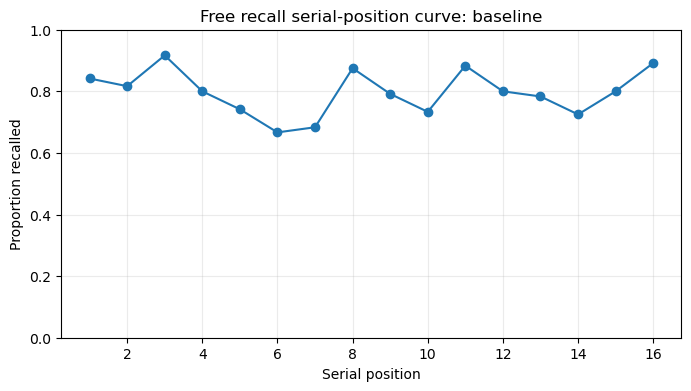

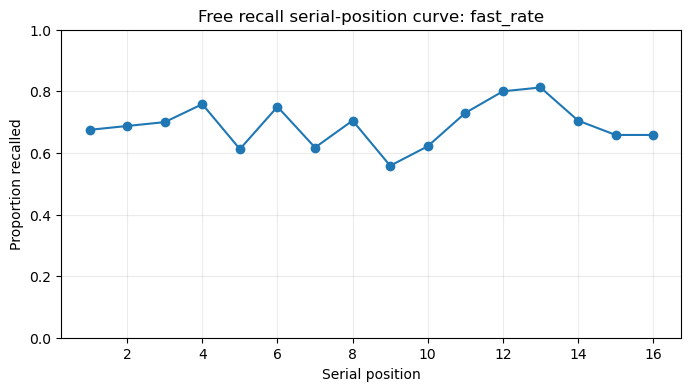

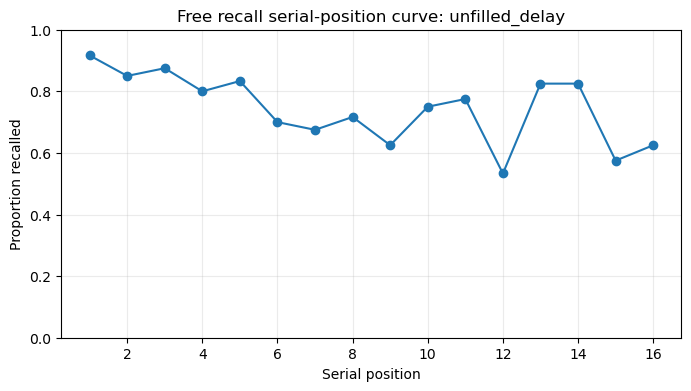

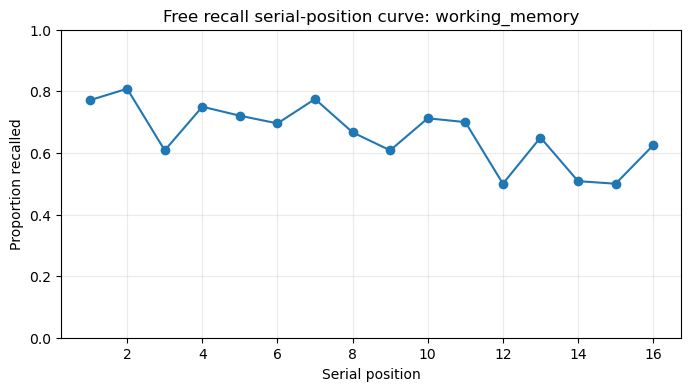

In [13]:
sp = (
    free_items.groupby(["condition", "serial_position"], as_index=False)["free_recalled"]
    .mean()
)

for condition, d in sp.groupby("condition"):
    plt.figure(figsize=(8, 4))
    plt.plot(d["serial_position"], d["free_recalled"], marker="o")
    plt.xlabel("Serial position")
    plt.ylabel("Proportion recalled")
    plt.ylim(0, 1)
    plt.title(f"Free recall serial-position curve: {condition}")
    plt.grid(alpha=0.25)
    plt.show()


In [14]:
for effect in ["primacy_index", "recency_index"]:
    rows = []
    for condition, d in free_trials.groupby("condition"):
        lo, hi = bootstrap_mean_ci(d[effect].dropna())
        rows.append({
            "condition": condition,
            "effect": effect,
            "mean": d[effect].mean(),
            "CI_low": lo,
            "CI_high": hi
        })
    display(pd.DataFrame(rows))


,condition,effect,mean,CI_low,CI_high
0,baseline,primacy_index,0.003889,-0.107222,0.112500
1,fast_rate,primacy_index,0.050722,-0.088279,0.177446
2,unfilled_delay,primacy_index,0.120833,0.027778,0.222222
3,working_memory,primacy_index,0.033194,-0.086948,0.160146


,condition,effect,mean,CI_low,CI_high
0,baseline,recency_index,0.006667,-0.066667,0.086667
1,fast_rate,recency_index,0.080333,-0.034008,0.195008
2,unfilled_delay,recency_index,-0.031667,-0.171667,0.110042
3,working_memory,recency_index,-0.135833,-0.276667,0.016667


# 2. Serial recall: capacity


,list_length,mean_letter_accuracy,mean_whole_sequence_accuracy,n_trials
0,4,0.958333,0.833333,6
1,5,1.000000,1.000000,4
2,6,1.000000,1.000000,4
3,7,1.000000,1.000000,4
4,8,0.875000,0.750000,4
5,9,0.833333,0.500000,4


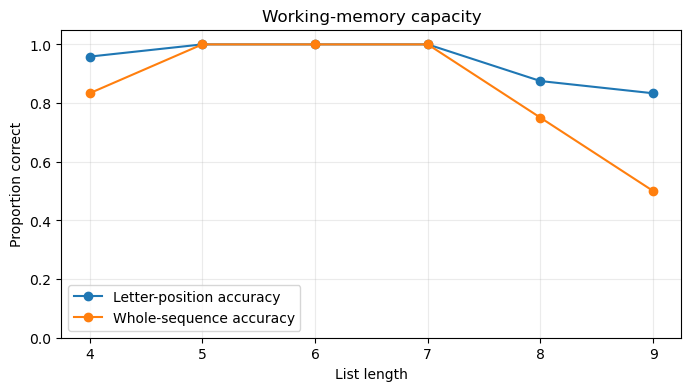

In [15]:
cap = trials[
    (trials["experiment"] == "serial_recall") &
    (trials["condition"].str.startswith("capacity_n"))
].copy()

cap["list_length"] = cap["condition"].str.extract(r"(\d+)").astype(int)
cap["whole_sequence_correct"] = (cap["serial_accuracy"] == 1).astype(int)

cap_summary = (
    cap.groupby("list_length", as_index=False)
    .agg(
        mean_letter_accuracy=("serial_accuracy", "mean"),
        mean_whole_sequence_accuracy=("whole_sequence_correct", "mean"),
        n_trials=("trial", "count")
    )
)
display(cap_summary)

plt.figure(figsize=(8, 4))
plt.plot(cap_summary["list_length"], cap_summary["mean_letter_accuracy"], marker="o", label="Letter-position accuracy")
plt.plot(cap_summary["list_length"], cap_summary["mean_whole_sequence_accuracy"], marker="o", label="Whole-sequence accuracy")
plt.xlabel("List length")
plt.ylabel("Proportion correct")
plt.ylim(0, 1.05)
plt.title("Working-memory capacity")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# 3. Serial recall: baseline vs tapping vs articulatory suppression


In [16]:
serial_main = trials[
    (trials["experiment"] == "serial_recall") &
    (trials["condition"].isin(["baseline", "finger_tapping", "articulatory_suppression"]))
].copy()

serial_summary = (
    serial_main.groupby("condition", as_index=False)
    .agg(
        mean_serial_accuracy=("serial_accuracy", "mean"),
        n=("serial_accuracy", "count"),
        mean_tap_count=("tap_count", "mean")
    )
)
display(serial_summary)


,condition,mean_serial_accuracy,n,mean_tap_count
0,articulatory_suppression,0.495833,20,0.00
1,baseline,0.541667,20,0.00
2,finger_tapping,0.691667,20,145.15


# 4. Error analysis


In [21]:
err = items[
    (items["experiment"] == "serial_recall") &
    (items["condition"].isin(["baseline", "finger_tapping", "articulatory_suppression"])) &
    (items["substitution"].notna()) &
    (items["substitution"].astype(str).str.len() > 0)
].copy()

pair_counts = (
    err.groupby(["condition", "presented_item", "substitution"])
    .size()
    .reset_index(name="count")
    .sort_values(["condition", "count"], ascending=[True, False])
)

display(pair_counts)


,condition,presented_item,substitution,count
18,articulatory_suppression,E,U,3
51,articulatory_suppression,L,N,3
6,articulatory_suppression,B,L,2
21,articulatory_suppression,G,B,2
23,articulatory_suppression,G,J,2
...,...,...,...,...
251,finger_tapping,X,N,1
253,finger_tapping,X,Y,1
254,finger_tapping,Y,F,1
256,finger_tapping,Y,S,1


# 6. Wordsporg / idiom block


,condition,mean_serial_accuracy,mean_free_accuracy,n_trials
0,fake_idioms,0.062500,0.083333,12
1,real_idioms,0.173611,0.250000,12


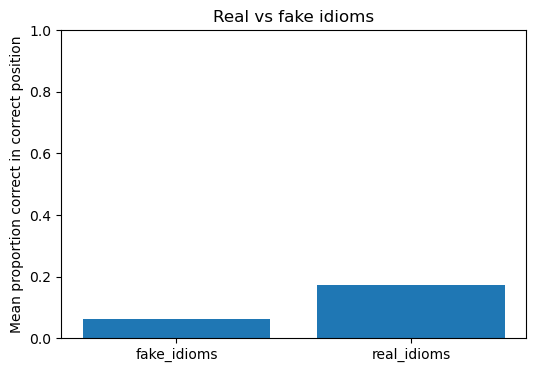

In [18]:
idiom_trials = trials[trials["experiment"] == "idiom_serial_recall"].copy()

idiom_summary = (
    idiom_trials.groupby("condition", as_index=False)
    .agg(
        mean_serial_accuracy=("serial_accuracy", "mean"),
        mean_free_accuracy=("free_accuracy", "mean"),
        n_trials=("trial", "count")
    )
)
display(idiom_summary)

plt.figure(figsize=(6, 4))
plt.bar(idiom_summary["condition"], idiom_summary["mean_serial_accuracy"])
plt.ylim(0, 1)
plt.ylabel("Mean proportion correct in correct position")
plt.title("Real vs fake idioms")
plt.xticks(rotation=0)
plt.show()


In [19]:
rows = []
for condition, d in idiom_trials.groupby("condition"):
    lo, hi = bootstrap_mean_ci(d["serial_accuracy"].dropna())
    rows.append({
        "condition": condition,
        "mean_serial_accuracy": d["serial_accuracy"].mean(),
        "CI_low": lo,
        "CI_high": hi
    })
display(pd.DataFrame(rows))


,condition,mean_serial_accuracy,CI_low,CI_high
0,fake_idioms,0.062500,0.027778,0.097222
1,real_idioms,0.173611,0.090278,0.263889


# 7. Participant-level overview


In [20]:
participant_summary = (
    trials.groupby(["participant", "experiment", "condition"], as_index=False)
    .agg(
        n_trials=("trial", "count"),
        free_accuracy=("free_accuracy", "mean"),
        serial_accuracy=("serial_accuracy", "mean"),
        primacy=("primacy_index", "mean"),
        recency=("recency_index", "mean")
    )
)
display(participant_summary)


,participant,experiment,condition,n_trials,free_accuracy,serial_accuracy,primacy,recency
0,Bert,free_recall,baseline,5,0.850000,0.050000,-0.237778,-0.066667
1,Bert,free_recall,fast_rate,5,0.762500,0.125000,0.102222,0.120000
2,Bert,free_recall,unfilled_delay,5,0.750000,0.237500,0.087778,-0.073333
3,Bert,free_recall,working_memory,5,0.712500,0.125000,0.147778,0.033333
4,Bert,idiom_serial_recall,fake_idioms,3,0.194444,0.111111,0.083333,0.250000
5,Bert,idiom_serial_recall,real_idioms,3,0.472222,0.388889,0.916667,0.500000
6,Bert,serial_recall,articulatory_suppression,5,0.566666,0.366667,0.341667,0.033333
7,Bert,serial_recall,baseline,5,0.650000,0.416667,0.183333,-0.283333
8,Bert,serial_recall,finger_tapping,5,0.650000,0.516667,0.033333,-0.233333
9,Chris,free_recall,baseline,5,0.675000,0.162500,0.134444,-0.006667


# 8. Notes for the report

You now have a cleaner write-up path:

## Free recall
- baseline serial-position curve
- primacy and recency indices
- compare baseline vs fast rate
- compare baseline vs unfilled delay
- compare baseline vs working-memory interference

## Serial recall
- capacity curve across list lengths
- baseline vs finger tapping
- baseline vs articulatory suppression
- substitution / error patterns

## Wordsporg / idioms
Treat this as an extra block:
- compare real idioms vs fake idioms
- report exact-position accuracy
- mention that this is an extra exploratory chunking-like manipulation if it is not strictly required by the assignment
